## Chain Of Thoughts With RAG

What is Chain-of-Thought (CoT) in RAG?

CoT reasoning breaks down a complex question into intermediate steps, and allows retrieval + reflection at each step before answering.

User Query
   ↓
- Step 1: Decompose question → sub-steps (Reason)
- Step 2: Retrieve docs per step (Act)
- Step 3: Combine context (Observe)
- Step 4: Final answer generation (Reflect)

In [2]:
import os
from typing import List
from pydantic import BaseModel
from langchain_core.documents import Document
from langchain_openai import OpenAIEmbeddings
from langchain_community.document_loaders import TextLoader
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import StateGraph, END

In [4]:
# 1. Prepare Vectorstore
docs = TextLoader("research_notes.txt", encoding="utf-8").load()
splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
chunks = splitter.split_documents(docs)

embedding = OpenAIEmbeddings()
vectorstore = FAISS.from_documents(chunks, embedding)
retriever = vectorstore.as_retriever()

In [5]:
import os
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv

os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
llm=init_chat_model("openai:gpt-4o")

In [6]:
# 2. LangGraph State Definition
class RAGCoTState(BaseModel):
    question: str
    sub_steps: List[str] = []
    retrieved_docs: List[Document] = []
    answer: str = ""

In [7]:
# 3. Nodes

# a. Plan sub-questions
def plan_steps(state:RAGCoTState)->RAGCoTState:
    prompt=f"Break the question into 2-3 reasoning steps: \n\n {state.question}"
    result=llm.invoke(prompt).content
    subqs=[line.strip("- ") for line in result.split("\n") if line.strip()]

    return state.model_copy(update={"sub_steps":subqs})


In [8]:
# b. Retrieve for each step
def retrieve_per_step(state:RAGCoTState)-> RAGCoTState:
    all_docs=[]
    for sub in state.sub_steps:
        docs = retriever.invoke(sub)
        all_docs.extend(docs)
    return state.model_copy(update={"retrieved_docs": all_docs})


In [9]:
# c. Generate Final Answer
def generate_answer(state: RAGCoTState) -> RAGCoTState:
    
    context = "\n\n".join([doc.page_content for doc in state.retrieved_docs])
    prompt = f"""
You are answering a complex question using reasoning and retrieved documents.

Question: {state.question}

Relevant Information:
{context}

Now synthesize a well-reasoned final answer.
"""
    result = llm.invoke(prompt).content.strip()
    return state.model_copy(update={"answer": result})

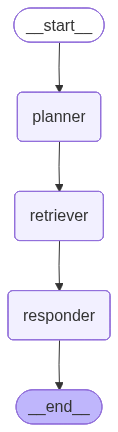

In [10]:
# 4. LangGraph Graph

builder = StateGraph(RAGCoTState)
builder.add_node("planner", plan_steps)
builder.add_node("retriever", retrieve_per_step)
builder.add_node("responder", generate_answer)

builder.set_entry_point("planner")
builder.add_edge("planner", "retriever")
builder.add_edge("retriever", "responder")
builder.add_edge("responder", END)

graph = builder.compile()
graph

In [11]:
# 5. Run CoT RAG Agent

if __name__ == "__main__":
    query = "what are the additional eperiments in Transformer eveluation?"
    state = RAGCoTState(question=query)
    final = graph.invoke(state)

    print("\nReasoning Steps:", final["sub_steps"])
    print("\nFinal Answer:\n", final["answer"])


Reasoning Steps: ['To determine what additional experiments might be necessary in the evaluation of Transformers, we can break this question down into several reasoning steps:', '1. **Identify the Standard Evaluation Metrics**:', 'Understand the current evaluation methods for Transformers, focusing on standard metrics such as accuracy, precision, recall, F1-score, BLEU, ROUGE, etc., depending on the specific task (e.g., translation, classification).', '2. **Determine Limitations and Gaps**:', 'Analyze the limitations or areas where current evaluations may not fully capture the capabilities or drawbacks of Transformers. This could include challenges in generalization, understanding context, handling long sequences, or being robust to adversarial inputs.', '3. **Propose Additional Experiments**:', 'Based on the identified gaps, design experiments that could address these issues. This might include robustness testing with adversarial examples, zero-shot learning assessments, efficiency a